In [ ]:
!pip install -q kagglehub

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("ulrikthygepedersen/online-retail-dataset")

print("Dataset downloaded to:")
print(path)

# Show files inside the dataset
for file in os.listdir(path):
    print(file)



import os

print("Files available in dataset folder:")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Using Colab cache for faster access to the 'online-retail-dataset' dataset.
Dataset downloaded to:
/kaggle/input/online-retail-dataset
online_retail.csv
Files available in dataset folder:
/kaggle/input/online-retail-dataset/online_retail.csv


In [ ]:
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download(
    "ulrikthygepedersen/online-retail-dataset"
)

print("Dataset location:")
print(path)

# Find the downloaded file
files = []

for root, dirs, filenames in os.walk(path):
    for file in filenames:
        files.append(os.path.join(root, file))

print("\nFiles found:")
for file in files:
    print(file)

# Load the first Excel/CSV file
data_file = None

for file in files:
    if file.lower().endswith((".xlsx", ".xls", ".csv")):
        data_file = file
        break

if data_file is None:
    print("\nNo Excel/CSV file found.")
else:
    print("\nLoading:", data_file)

    if data_file.lower().endswith(".csv"):
        df = pd.read_csv(data_file)
    else:
        df = pd.read_excel(data_file)

    print("\nDataset loaded successfully!")
    print("Shape:", df.shape)

    display(df.head())


# STEP 4: Dataset Inspection

print("===== DATASET INFORMATION =====")

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Dataset shape
print("\nRows and Columns:")
print(df.shape)

# Data types and non-null values
print("\nData Types & Non-Null Values:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Using Colab cache for faster access to the 'online-retail-dataset' dataset.
Dataset location:
/kaggle/input/online-retail-dataset

Files found:
/kaggle/input/online-retail-dataset/online_retail.csv

Loading: /kaggle/input/online-retail-dataset/online_retail.csv

Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


===== DATASET INFORMATION =====

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Rows and Columns:
(541909, 8)

Data Types & Non-Null Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country   

In [ ]:
# STEP 5: Data Cleaning

# Make a copy of the original dataset
df_clean = df.copy()

print("Original Shape:", df_clean.shape)

# Remove rows where CustomerID is missing
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove rows with missing InvoiceDate
df_clean = df_clean.dropna(subset=['InvoiceDate'])

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(
    df_clean['InvoiceDate'],
    errors='coerce'
)

# Remove invalid dates
df_clean = df_clean.dropna(subset=['InvoiceDate'])

# Keep only positive quantity
df_clean = df_clean[df_clean['Quantity'] > 0]

# Keep only positive unit price
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("\nCleaned Shape:", df_clean.shape)

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df_clean.duplicated().sum())

display(df_clean.head())


Original Shape: (541909, 8)

Cleaned Shape: (392692, 8)

Missing Values After Cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate Rows After Cleaning:
0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# STEP 6.1: Calculate Total Amount

df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

display(df_clean.head())
# STEP 6.2: Set the reference date

reference_date = df_clean['InvoiceDate'].max()

print("Latest Transaction Date:", reference_date)
# STEP 6.3: Create RFM table

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (
        reference_date - x.max()
    ).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

# Rename columns
rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

print("RFM Table:")
display(rfm.head())

print("\nRFM Shape:", rfm.shape)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Latest Transaction Date: 2011-12-09 12:50:00
RFM Table:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40



RFM Shape: (4338, 4)


===== RFM DESCRIPTIVE STATISTICS =====


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


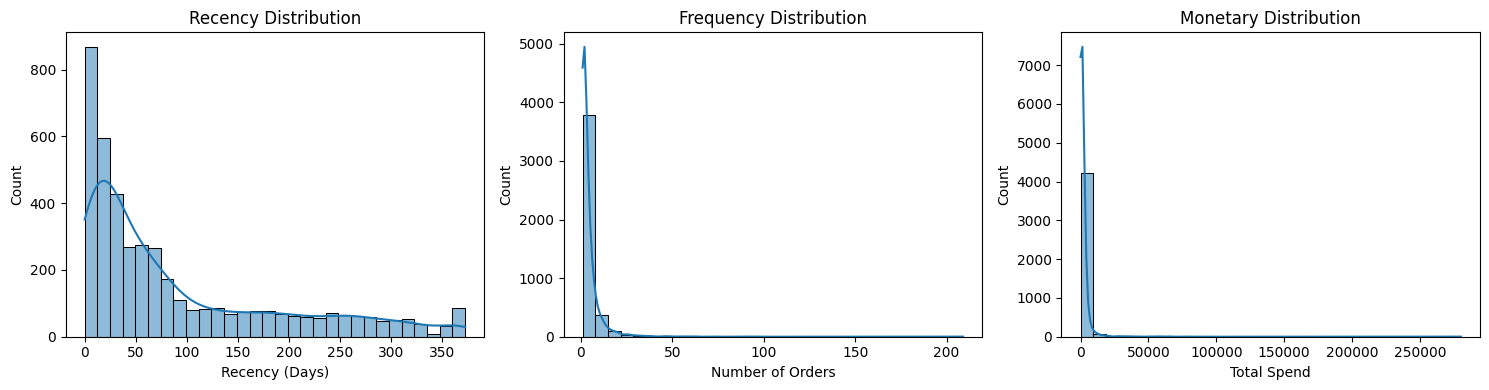

Features selected for clustering:
['Recency', 'Frequency', 'Monetary']


,Recency,Frequency,Monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


In [ ]:
# STEP 7.1: RFM Descriptive Statistics

print("===== RFM DESCRIPTIVE STATISTICS =====")

display(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# STEP 7.2: Check RFM distributions

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Recency Distribution')
plt.xlabel('Recency (Days)')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Frequency Distribution')
plt.xlabel('Number of Orders')

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Monetary Distribution')
plt.xlabel('Total Spend')

plt.tight_layout()
plt.show()

# STEP 7.3: Select RFM features for clustering

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

print("Features selected for clustering:")
print(rfm_features.columns.tolist())

display(rfm_features.head())

In [ ]:
# STEP 8.1: Standardize RFM Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print("RFM features standardized successfully!")
print("Scaled data shape:", rfm_scaled.shape)

# STEP 8.2: Create scaled RFM DataFrame

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

display(rfm_scaled_df.head())


RFM features standardized successfully!
Scaled data shape: (4338, 3)


,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


Inertia values:
K = 2: 9014.57
K = 3: 5441.32
K = 4: 4096.30
K = 5: 3119.79
K = 6: 2473.79
K = 7: 2023.59
K = 8: 1717.01
K = 9: 1468.79
K = 10: 1281.05


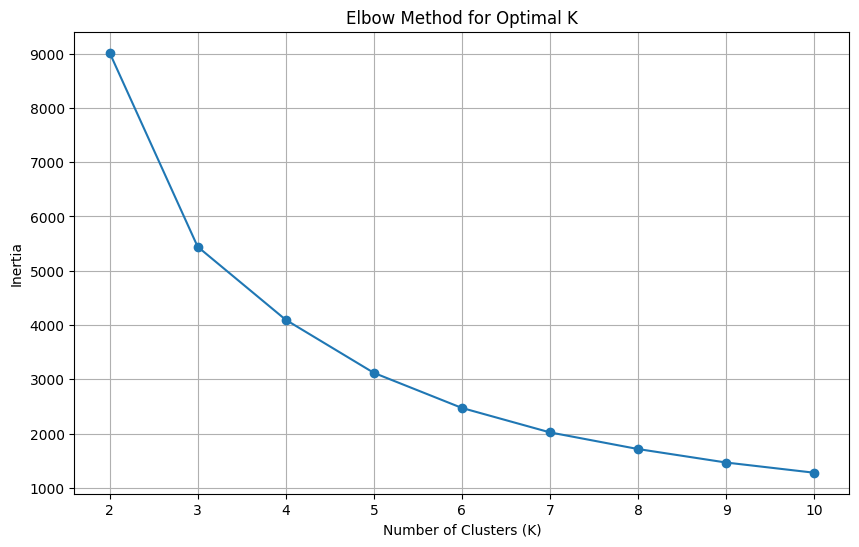

In [ ]:
# STEP 9: Elbow Method

from sklearn.cluster import KMeans

inertia = []

# Test K values from 2 to 10
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: {value:.2f}")

  # Plot Elbow Curve

plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.grid(True)
plt.show()



In [ ]:
# STEP 10: K-Means Clustering

optimal_k = 4   # Change this based on your Elbow Method result

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed!")
print("Number of clusters:", optimal_k)

display(rfm.head())

# Customer count in each cluster

cluster_counts = rfm['Cluster'].value_counts().sort_index()

print("Customers in each cluster:")
display(cluster_counts)

# STEP 10.3: Profile each customer cluster

cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).reset_index()

cluster_profile.rename(
    columns={'CustomerID': 'CustomerCount'},
    inplace=True
)

display(cluster_profile)

K-Means clustering completed!
Number of clusters: 4


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,325,1,77183.60,3
1,12347.0,1,7,4310.00,0
2,12348.0,74,4,1797.24,0
3,12349.0,18,1,1757.55,0
4,12350.0,309,1,334.40,1


Customers in each cluster:


,count
Cluster,
0,3054
1,1067
2,13
3,204


,Cluster,Recency,Frequency,Monetary,CustomerCount
0,0,42.702685,3.682711,1353.625312,3054
1,1,247.075914,1.552015,478.848773,1067
2,2,6.384615,82.538462,127187.959231,13
3,3,14.500000,22.333333,12690.500392,204


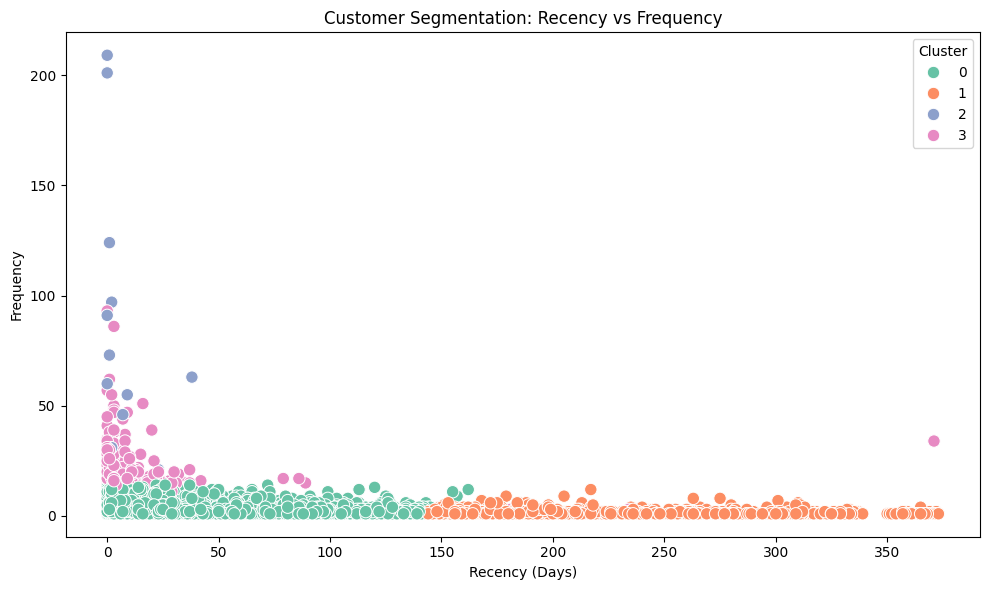

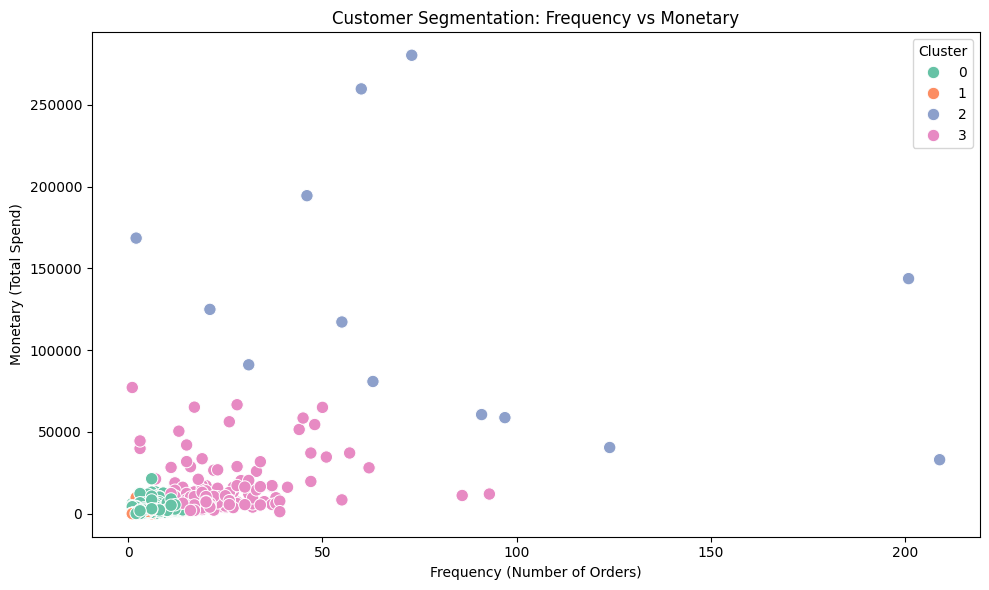

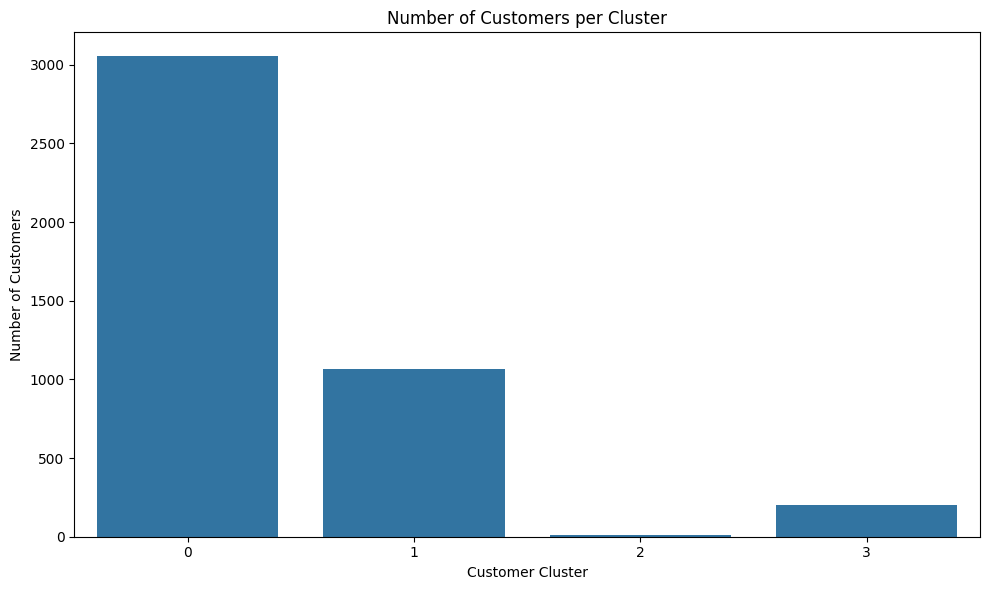

In [ ]:
# STEP 11.1: Recency vs Frequency

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='Set2',
    s=80
)

plt.title('Customer Segmentation: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

# STEP 11.2: Frequency vs Monetary

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=80
)

plt.title('Customer Segmentation: Frequency vs Monetary')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Spend)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

# STEP 11.3: Number of Customers per Cluster

plt.figure(figsize=(10, 6))

sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [ ]:
# STEP 12.1: Display Cluster Profile

cluster_profile = cluster_profile.sort_values(
    'Monetary',
    ascending=False
)

display(cluster_profile)

# STEP 12.2: Assign Customer Segment Names

def assign_segment(row):
    if row['Frequency'] >= cluster_profile['Frequency'].median() and \
       row['Monetary'] >= cluster_profile['Monetary'].median():
        return 'High Value Customers'

    elif row['Recency'] <= cluster_profile['Recency'].median():
        return 'Recent Customers'

    elif row['Frequency'] < cluster_profile['Frequency'].median():
        return 'Low Frequency Customers'

    else:
        return 'At Risk Customers'


cluster_profile['Segment'] = cluster_profile.apply(
    assign_segment,
    axis=1
)

display(cluster_profile)

# Add segment names to each customer

segment_mapping = cluster_profile.set_index(
    'Cluster'
)['Segment'].to_dict()

rfm['Segment'] = rfm['Cluster'].map(segment_mapping)

display(rfm.head())



,Cluster,Recency,Frequency,Monetary,CustomerCount
2,2,6.384615,82.538462,127187.959231,13
3,3,14.500000,22.333333,12690.500392,204
0,0,42.702685,3.682711,1353.625312,3054
1,1,247.075914,1.552015,478.848773,1067


,Cluster,Recency,Frequency,Monetary,CustomerCount,Segment
2,2,6.384615,82.538462,127187.959231,13,High Value Customers
3,3,14.500000,22.333333,12690.500392,204,High Value Customers
0,0,42.702685,3.682711,1353.625312,3054,Low Frequency Customers
1,1,247.075914,1.552015,478.848773,1067,Low Frequency Customers


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,325,1,77183.60,3,High Value Customers
1,12347.0,1,7,4310.00,0,Low Frequency Customers
2,12348.0,74,4,1797.24,0,Low Frequency Customers
3,12349.0,18,1,1757.55,0,Low Frequency Customers
4,12350.0,309,1,334.40,1,Low Frequency Customers


,Segment,CustomerCount,Recency,Frequency,Monetary
0,High Value Customers,217,14.013825,25.940092,19549.795161
1,Low Frequency Customers,4121,95.618539,3.131036,1127.130149


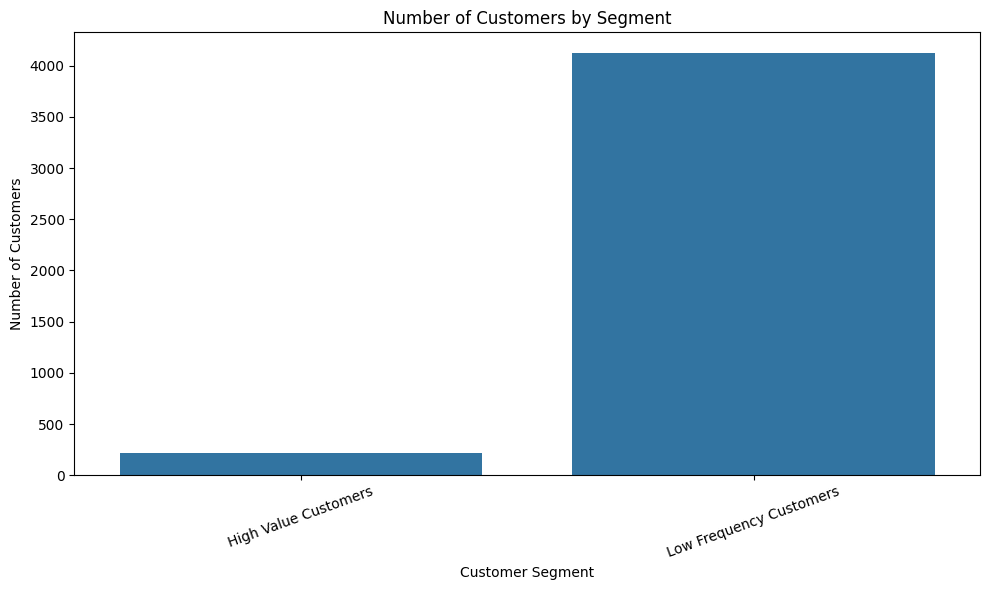

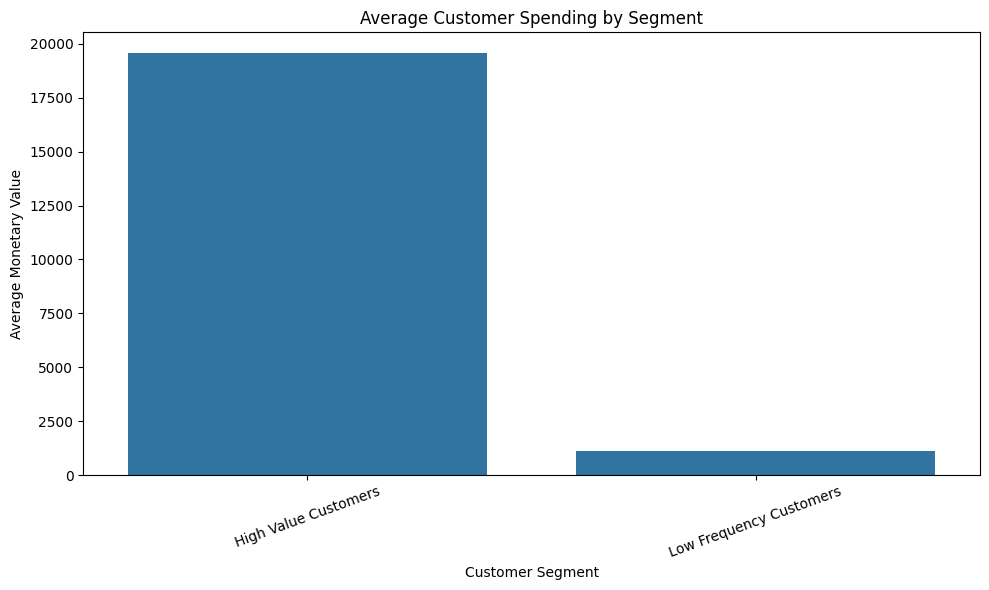

In [ ]:
# STEP 13.1: Final Segment Summary

segment_summary = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()

segment_summary.rename(
    columns={'CustomerID': 'CustomerCount'},
    inplace=True
)

display(segment_summary)

# STEP 13.2: Customer Count by Segment

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x='Segment',
    y='CustomerCount'
)

plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# STEP 13.3: Average Monetary Value by Segment

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x='Segment',
    y='Monetary'
)

plt.title('Average Customer Spending by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
# Final Customer Segmentation Results

print("===== FINAL CUSTOMER SEGMENTATION RESULTS =====")

display(
    segment_summary.sort_values(
        'Monetary',
        ascending=False
    )
)

# Save final customer segmentation data

rfm.to_csv(
    'customer_segmentation_results.csv',
    index=False
)

print("customer_segmentation_results.csv saved successfully!")

# Save segment summary

segment_summary.to_csv(
    'customer_segment_summary.csv',
    index=False
)

print("customer_segment_summary.csv saved successfully!")

===== FINAL CUSTOMER SEGMENTATION RESULTS =====


,Segment,CustomerCount,Recency,Frequency,Monetary
0,High Value Customers,217,14.013825,25.940092,19549.795161
1,Low Frequency Customers,4121,95.618539,3.131036,1127.130149


customer_segmentation_results.csv saved successfully!
customer_segment_summary.csv saved successfully!


# Conclusion

The Customer Segmentation Analysis successfully grouped customers
based on their purchasing behaviour using RFM analysis and K-Means
clustering.

The analysis considered three important customer behaviour metrics:

- Recency
- Frequency
- Monetary Value

The Elbow Method was used to determine a suitable number of clusters,
and StandardScaler was applied before K-Means clustering.

The resulting customer segments provide useful insights into
different purchasing behaviours.

## Key Business Recommendations

1. Retain high-value customers through loyalty programs and exclusive
   offers.

2. Encourage recent customers to make repeat purchases through
   personalized recommendations.

3. Improve engagement among low-frequency customers using targeted
   promotions and discounts.

4. Re-engage at-risk customers through personalized retention
   campaigns.

5. Continuously monitor customer RFM metrics to identify changes in
   purchasing behaviour.